# Predicting Insurance Claim Amounts
This notebook aims to estimate medical insurance charges based on personal data such as age, BMI, and smoking status. We will utilize Linear Regression and evaluate the model's accuracy.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset
insurance_df = pd.read_csv('/content/insurance.csv')
display(insurance_df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 1. Data Visualization and Analysis
We will visualize the impact of Age, BMI, and Smoking status on insurance charges to identify key trends.

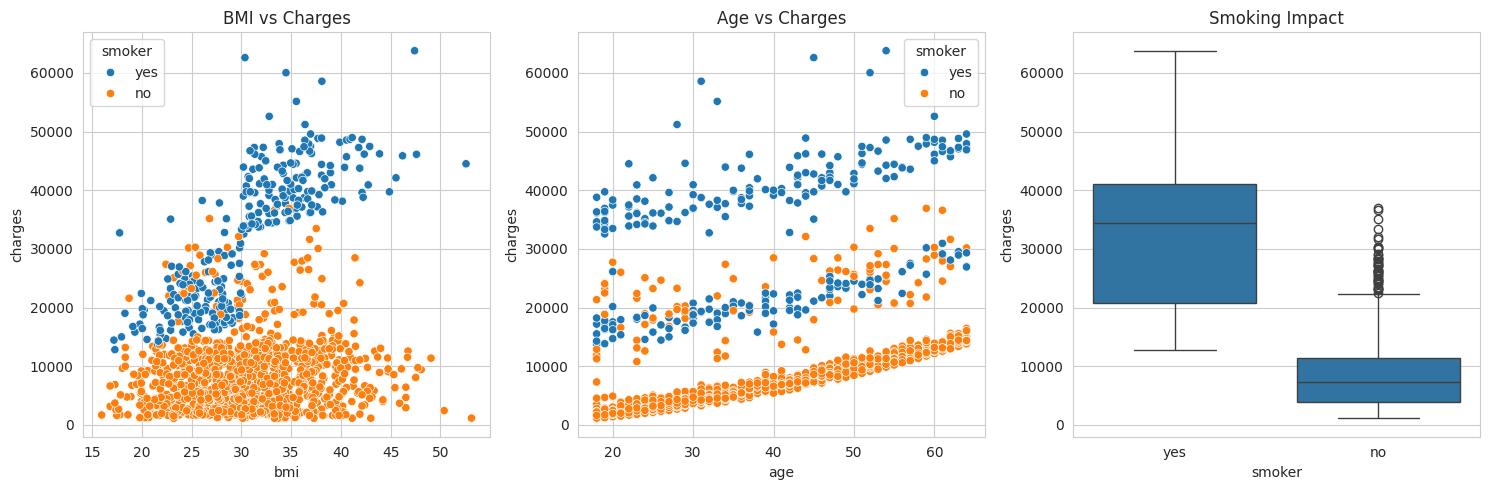

In [35]:
plt.figure(figsize=(15, 5))

# BMI vs Charges
plt.subplot(1, 3, 1)
sns.scatterplot(data=insurance_df, x='bmi', y='charges', hue='smoker')
plt.title('BMI vs Charges')

# Age vs Charges
plt.subplot(1, 3, 2)
sns.scatterplot(data=insurance_df, x='age', y='charges', hue='smoker')
plt.title('Age vs Charges')

# Smoking Status vs Charges
plt.subplot(1, 3, 3)
sns.boxplot(data=insurance_df, x='smoker', y='charges')
plt.title('Smoking Impact')

plt.tight_layout()
plt.show()

### 2. Model Training
We convert categorical data into numerical format and train a Linear Regression model.

In [36]:
# Convert 'smoker' and 'sex' to numerical using one-hot encoding
insurance_processed = pd.get_dummies(insurance_df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = insurance_processed.drop('charges', axis=1)
y = insurance_processed['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

LinearRegression()

### 3. Model Evaluation
Evaluating the model using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [37]:
y_pred = reg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

Mean Absolute Error (MAE): $4,181.19
Root Mean Squared Error (RMSE): $5,796.28


## Final Summary of Insurance Task

### **Model Performance Metrics**
- **Model Used:** Linear Regression
- **Mean Absolute Error (MAE):** $4,181.19
- **Root Mean Squared Error (RMSE):** $5,796.28

### **Key Findings**
1. **Primary Drivers:** Smoking status and BMI (Body Mass Index) showed the strongest positive correlation with medical charges.
2. **Demographics:** Age also plays a consistent role in predicting base insurance costs.
3. **Methodology:** categorical variables (sex, smoker, region) were successfully transformed using one-hot encoding to allow for regression analysis.

### **Conclusion**
All three machine learning tasks—Loan Approval, Bank Churn, and Insurance Claims—have been successfully implemented and documented with clean code and clear summaries.